In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent)) 

### Object detection

In [ ]:
from data.dataset import Custom3DDataset, ObjectDataset
from data.preprocess import extract_objects, preprocess_object

data_path = "/media/void/Crucial X8/dl_challenge/dl_challenge"
scene_dataset = Custom3DDataset(data_path)

all_objects = []

for sample in scene_dataset:
    objects = extract_objects(sample)

    for obj in objects:
        processed = preprocess_object(obj)
        all_objects.append(processed)

dataset = ObjectDataset(all_objects)

In [ ]:
from src.logging.mlflow_logger import MLflowLogger
from src.train.trainer import Trainer
from torch.utils.data import DataLoader
from src.model import PointNetBBox
import torch

device = 'cuda' if torch.cuda.is_available() else 'cpu'

loader = DataLoader(
    dataset,
    batch_size=16,
    shuffle=True,
    num_workers=2
)

model = PointNetBBox().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

logger = MLflowLogger("test_")
logger.log_params({"lr": 1e-3, "batch_size": 16})

trainer = Trainer(model, optimizer, loader, logger, device)
trainer.train(epochs=20)

/home/void/3d_boundingbox_prediction/.venv/lib/python3.13/site-packages/mlflow/utils/autologging_utils/versioning.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename
2026/04/11 15:12:45 INFO mlflow.tracking.fluent: Experiment with name 'test_' does not exist. Creating a new experiment.


Epoch 0: Loss = 3.4212
Epoch 1: Loss = 3.0382
Epoch 2: Loss = 2.8918
Epoch 3: Loss = 2.7351
Epoch 4: Loss = 2.7214
Epoch 5: Loss = 2.6867
Epoch 6: Loss = 2.6970
Epoch 7: Loss = 2.6689
Epoch 8: Loss = 2.6969
Epoch 9: Loss = 2.6217
Epoch 10: Loss = 2.5898
Epoch 11: Loss = 2.5595
Epoch 12: Loss = 2.6096
Epoch 13: Loss = 2.5200
Epoch 14: Loss = 2.4803
Epoch 15: Loss = 2.4547
Epoch 16: Loss = 2.4886
Epoch 17: Loss = 2.4833
Epoch 18: Loss = 2.2827
Epoch 19: Loss = 2.3993


2.2827021994938455

In [ ]:
import numpy as np
from data.dataset import Custom3DDataset
from data.preprocess import extract_objects,denormalize_prediction, param_to_box, preprocess_object
from scripts.train import load_split

data_path = "/media/void/Crucial X8/dl_challenge/dl_challenge"
dataset = Custom3DDataset(data_path)
test_sample = load_split(dataset, path="../data/splits.npz")[2]

sample = test_sample[5]
objects = extract_objects(sample)
all_objects = []
for obj in objects:
    processed = preprocess_object(obj)
    all_objects.append(processed)


In [22]:
import torch
from src.model import PointNetBBox

device = 'cuda' if torch.cuda.is_available() else 'cpu'

model = PointNetBBox().to(device)
checkpoint = torch.load("/home/void/3d_boundingbox_prediction/outputs/best_model.pth", map_location=device)
# Load weights
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

PointNetBBox(
  (mlp1): Sequential(
    (0): Linear(in_features=3, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=256, bias=True)
    (5): ReLU()
  )
  (fc): Sequential(
    (0): Linear(in_features=256, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=7, bias=True)
  )
)

In [23]:
pred_bboxes = []
for obj in all_objects:
    with torch.no_grad():
        points = torch.tensor(obj["points"], dtype=torch.float32).unsqueeze(0).cuda()

        pred_center, pred_size, pred_yaw = model(points)

        pred_center = pred_center.cpu().numpy()[0]
        pred_size = pred_size.cpu().numpy()[0]
        pred_yaw = pred_yaw.cpu().numpy()[0]

        # convert back to scene
        center, size = denormalize_prediction(pred_center, pred_size, obj)

        # box corners
        pred_box = param_to_box(center, size, pred_yaw)
        pred_bboxes.append(pred_box)

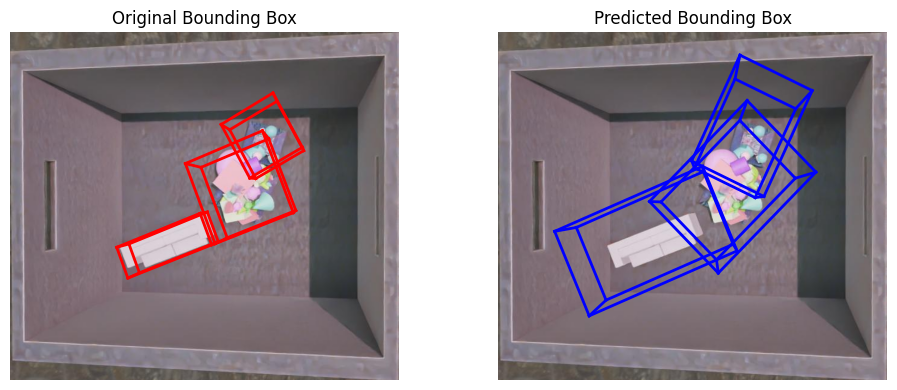

In [24]:
from src.visualize import Visualizer
import matplotlib.pyplot  as plt


vis = Visualizer(sample)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
vis.show(show_pc=False, show_boxes=True, show_mask=False, ax=ax1)
ax1.set_title("Original Bounding Box")

vis.boxes = pred_bboxes
vis.show(show_pc=False, show_boxes=True, show_mask=False, box_color='b', ax=ax2)
ax2.set_title("Predicted Bounding Box")

plt.tight_layout()
plt.show()

Pipeline works!